In [14]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.model_selection import GridSearchCV



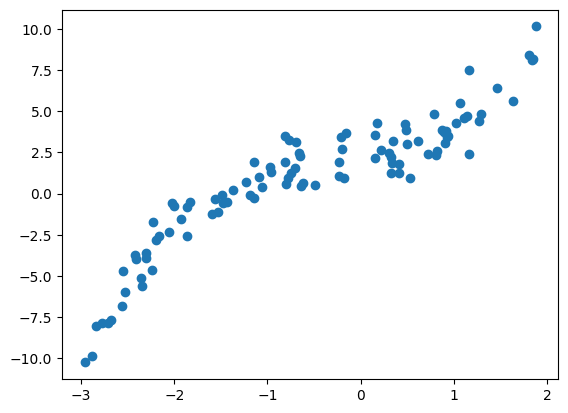

In [15]:
#New way of generating data, using the new random generator.
rng = np.random.default_rng(42)
X = 5 * rng.random((100, 1)) - 3
y = 0.6*X**3 + 0.6 * X**2 + 0.7*X + 2 + rng.normal(size=(100, 1))


plt.scatter(X, y)

In [16]:
X_new = np.linspace(-3, 2.5, 20).reshape(-1, 1)

In [17]:
pipeline = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1))
])

y_lr = pipeline.fit(X, y)
y_lr_pred = y_lr.predict(X_new)

In [18]:
pipeline.get_params()

{'memory': None,
 'steps': [('poly', PolynomialFeatures(include_bias=False)),
  ('ridge', Ridge(alpha=1))],
 'transform_input': None,
 'verbose': False,
 'poly': PolynomialFeatures(include_bias=False),
 'ridge': Ridge(alpha=1),
 'poly__degree': 2,
 'poly__include_bias': False,
 'poly__interaction_only': False,
 'poly__order': 'C',
 'ridge__alpha': 1,
 'ridge__copy_X': True,
 'ridge__fit_intercept': True,
 'ridge__max_iter': None,
 'ridge__positive': False,
 'ridge__random_state': None,
 'ridge__solver': 'auto',
 'ridge__tol': 0.0001}

In [19]:
param_grid = [
    {"poly__degree": [1,2,3,4,5,6], "ridge__alpha": [0.5, 1, 1.5]}
]

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ge(alpha=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'poly__degree': [1, 2, ...], 'ridge__alpha': [0.5, 1, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [20]:
grid_search.best_params_

{'poly__degree': 3, 'ridge__alpha': 1}

In [21]:
y_best_pred = grid_search.predict(X_new)

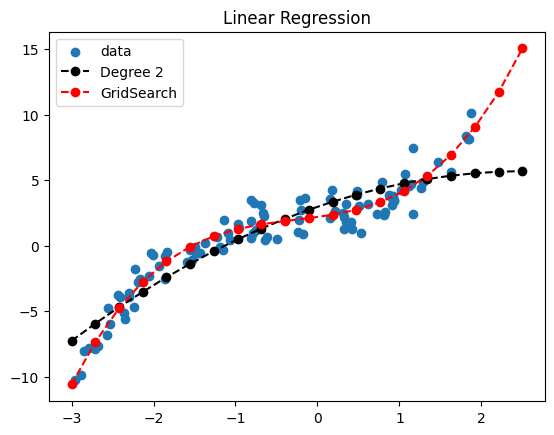

In [22]:
fig, ax = plt.subplots()
ax.set_title("Linear Regression")
ax.scatter(X, y, label="data")
ax.plot(X_new, y_lr_pred, 'k--o', label='Degree 2')
ax.plot(X_new, y_best_pred, 'r--o', label='GridSearch')
ax.legend()
